<h1><center>Data Plotting</center></h1>
<hr>
<br><br>

This Jupyterlab notebook contains the data post-processing of the outliers diagnostic tests

In [1]:
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline
%config InlineBackend.figure_formats = "svg",

# Settings template for matplotlib
plt.style.use("LabReport.mplstyle")

## 14 min acquisition with reference weight of 33.6 g

Mean = 33.595


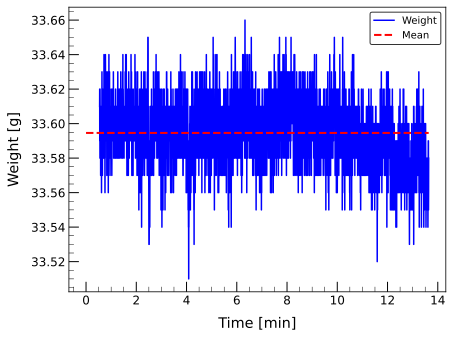

In [2]:
t, w = np.loadtxt("sessions/20240918/20240918.txt", skiprows=1, unpack=True, delimiter=",")
t /= 60
print(f"Mean = {w.mean():.3f}")

plt.plot(t, w, "b", label="Weight")
plt.hlines(w.mean(), 0, t[-1], ls="--", lw=2, color="r", label="Mean")
plt.xlabel("Time [min]")
plt.ylabel("Weight [g]")
plt.legend()
# plt.savefig("data/20240918/20240918_StableWeight")
plt.show()

## 60 min acquisition with reference weight of 33.6 g

Mean = 33.771


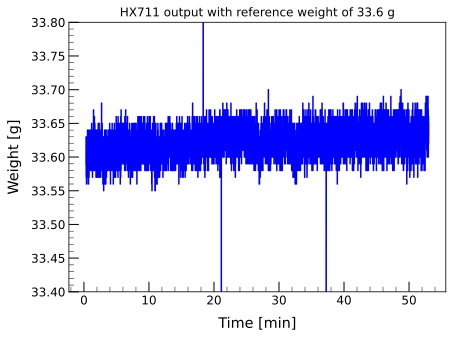

In [3]:
t, w = np.loadtxt("sessions/20240925/20240925_33.6g.txt", skiprows=1, unpack=True, delimiter=",")
print(f"Mean = {w.mean():.3f}")

plt.plot(t, w, "b", label="Weight")
# plt.hlines(w.mean(), 0, t[-1], ls="--", lw=2, color="r", label="Mean")
plt.xlabel("Time [min]")
plt.ylabel("Weight [g]")
plt.ylim((33.4, 33.8))
# plt.legend()
plt.title("HX711 output with reference weight of 33.6 g")
# plt.savefig("data/20240925/20240925_StableWeight_Crop")
plt.show()

## 60 min acquisition with HX711's differential input pins to GND 

Mean = -0.036


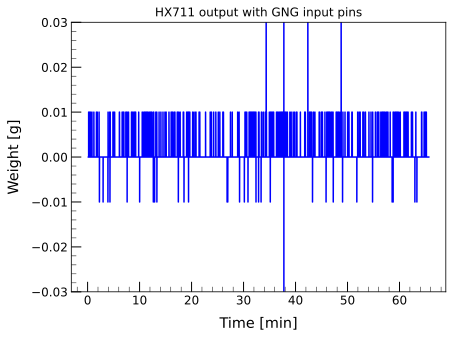

In [4]:
t, w = np.loadtxt("sessions/20240925/20240925_HX711_GNDinputs.txt", skiprows=1, unpack=True, delimiter=",")
print(f"Mean = {w.mean():.3f}")

plt.plot(t, w, "b", label="Weight")
# plt.hlines(w.mean(), 0, t[-1], ls="--", lw=2, color="r", label="Mean")
plt.xlabel("Time [min]")
plt.ylabel("Weight [g]")
plt.ylim((-0.03, 0.03))
# plt.legend()
plt.title("HX711 output with GNG input pins")
# plt.savefig("data/20240925/20240925_GNDinputs_Crop")
plt.show()

## Power line ripples

### Quick test (DC Coupled)

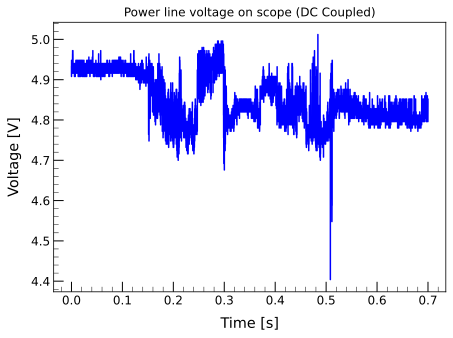

In [5]:
t, v = np.loadtxt("sessions/20240926/data/PowerLine/1_VCCprobe_NoWeight/data.csv", skiprows=12, unpack=True, delimiter=",")
t -= t[0]
# print(f"Mean = {v.mean():.3f}")

plt.plot(t, v, "b", label="Voltage")
# plt.hlines(w.mean(), 0, t[-1], ls="--", lw=2, color="r", label="Mean")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
# plt.ylim((-0.03, 0.03))
# plt.legend()
plt.title("Power line voltage on scope (DC Coupled)")
# plt.savefig("sessions/20240926/20240926_PowerLine")
plt.show()

## Arduino Uno R3 SCK singal on scope

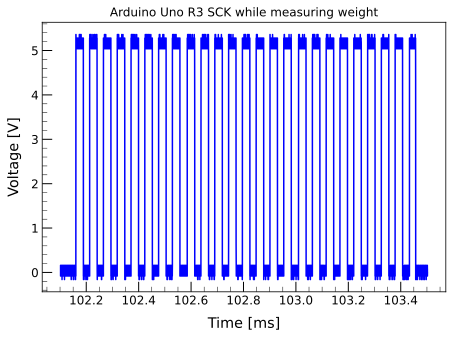

In [11]:
# t, v = np.loadtxt("sessions/20241001/data/SCK_arduino_uno_r3.txt", skiprows=12, unpack=True)
t, v = np.loadtxt("sessions/20241001/data/SCK_arduino_uno_r3.csv", skiprows=12, unpack=True, delimiter=",")

plt.plot(t / 1e-3, v, "b", label="Voltage")
plt.xlabel("Time [ms]")
plt.ylabel("Voltage [V]")
# plt.ylim((-0.03, 0.03))
# plt.legend()
plt.title("Arduino Uno R3 SCK while measuring weight")
# plt.savefig("sessions/20241001/20241001_ArduinoUnoR3_SCK_full")
plt.show()

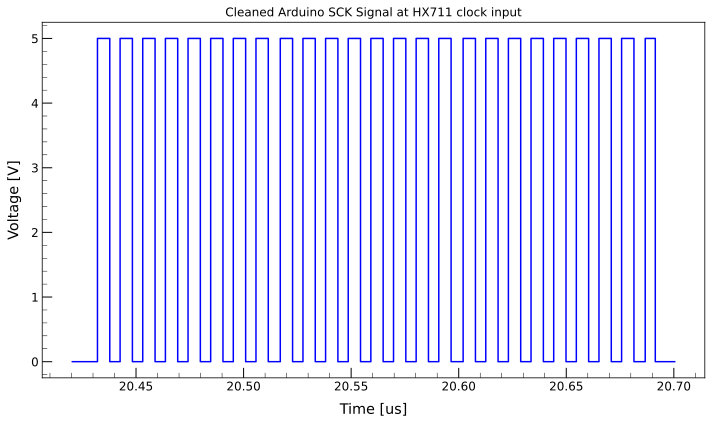

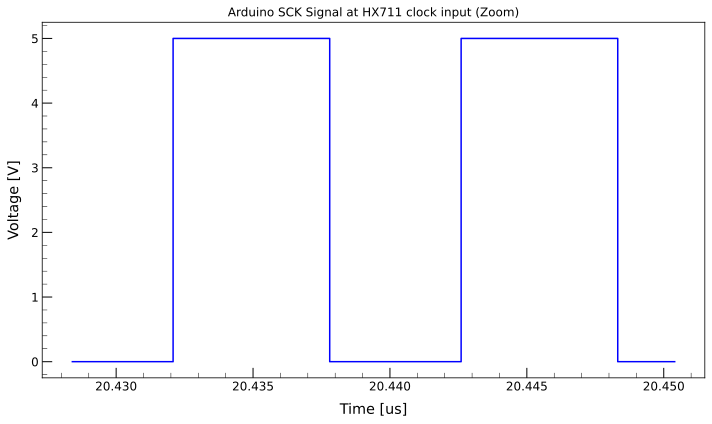

In [15]:
# Function to clean the voltage values
def clean_voltage_signal(voltage, low_threshold=0.1, high_threshold=4.9):
    """
    Adjusts all values close to 0V to exactly 0, and those close to 5V to exactly 5V.
    """
    v_clean = np.copy(voltage)
    v_clean[voltage < low_threshold] = 0
    v_clean[voltage > -low_threshold] = 0
    v_clean[voltage > high_threshold] = 5
    return v_clean

# Clean the voltage data
v_clean = clean_voltage_signal(v)

# Plot the cleaned signal
plt.figure(figsize=(10, 6))
plt.plot(t * 200, v_clean, "b")
plt.title("Cleaned Arduino SCK Signal at HX711 clock input")
plt.xlabel("Time [us]")
plt.ylabel("Voltage [V]")
# plt.savefig("sessions/20241001/20241001_ArduinoUnoR3_SCK_full")
plt.show()

# Zoom on 1-2 duty cycle
plt.figure(figsize=(10, 6))
plt.plot(t[20000:75000] * 200, v_clean[20000:75000], "b")
plt.title("Arduino SCK Signal at HX711 clock input (Zoom)")
plt.xlabel("Time [us]")
plt.ylabel("Voltage [V]")
# plt.savefig("sessions/20241001/20241001_ArduinoUnoR3_SCK_cycle")
plt.show()


## HX711 raw output with FireBeetle

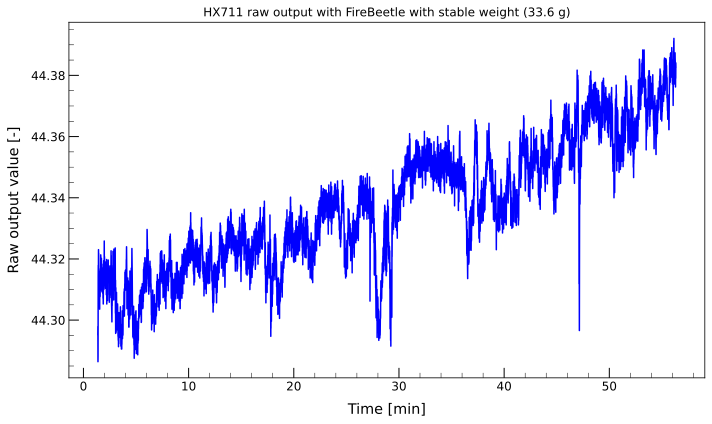

In [9]:
t, v = np.loadtxt("sessions/20241001/data/20241001_FireBeetleClock.txt", skiprows=12, unpack=True, delimiter=",")

plt.figure(figsize=(10, 6))
plt.plot(t[175:], v[175:]/-5300, "b")
plt.xlabel("Time [min]")
plt.ylabel("Raw output value [-]")
plt.title("HX711 raw output with FireBeetle with stable weight (33.6 g)")
# plt.savefig("sessions/20241001/20241001_HX711outputFireBeetle")
plt.show()